# Notebook 7 - Battery Arbitrage Optimization

## Overview

This notebook translates the Alberta market analysis into an asset-level decision problem. It estimates the historical energy-arbitrage value available to a stylized battery, identifies when the value was created, and tests how results change with bettery design and operating assumptions. 

The notebook asks: 

1. How much perfect-foresight arbitrage value was availble from 2015 - 2025? 
2. How did value change across Alberta's market regimes? 
3. How concentrated was revenue in a small number of extreme-price events? 
4. How sensitive is value to duration, efficiency, power, and degradation cost? 
5. How much of the perfect-foresight upper boundcan simple casual strategies capture? 

This is an energy-only historical simulation, not a complete investment valuation. It excludes capital cost, fixed operating cost, ancillary-service revenue, price impact, market feets, forced outages, and detailed electrochemical degradation.

In [31]:
# ---------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------

from dataclasses import dataclass, replace
from itertools import product
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from scipy.optimize import linprog
from scipy.sparse import lil_matrix

from config import MASTER_PARQUET

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

STUDY_START_YEAR = 2015
STUDY_END_YEAR = 2025

RUN_FULL_STUDY = True

## 1. Battery model

Charge and discharge are measured on the grid side, while state of charge is measured inside the battery: 

$$
SOC_{t+1}
=
(1-\lambda)SOC_t
+
\eta_c C_t\Delta t
-
\frac{D_t\Delta t}{\eta_d}
$$

subject to:

$$
0 \le SOC_t \le E_{\max}
$$

$$
0 \le C_t,D_t \le P_{\max}
$$

The objective is: 

$$
\max
\sum_t
\left[
p_t(D_t-C_t)\Delta t
-
c_{\mathrm{deg}}(C_t+D_t)\Delta t
\right]
$$

Initial and terminal state of charge are set equal so the optimizer cannot create artificial value by emptying the battery at the end of the horizon. 

In [32]:
# ---------------------------------------------------------------------
# Battery configuration
# ---------------------------------------------------------------------

@dataclass(frozen = True)
class BatteryConfig:
    power_mw: float = 100.0
    energy_mwh: float = 200.0
    round_trip_efficiency: float = 0.88
    degradation_cost_per_mwh: float = 2.0
    initial_soc_mwh: float | None = None
    terminal_soc_mwh: float | None = None
    self_discharge_per_hour: float = 0.0

    @property 
    def charge_efficiency(self): 
        return np.sqrt(self.round_trip_efficiency)

    @property
    def discharge_efficiency(self): 
        return np.sqrt(self.round_trip_efficiency)

    @property
    def resolved_initial_soc(self):
        if self.initial_soc_mwh is None: 
            return 0.5 * self.energy_mwh
        return self.initial_soc_mwh

    @property
    def resolved_terminal_soc(self):
        if self.terminal_soc_mwh is None: 
            return 0.5 * self.energy_mwh
        return self.terminal_soc_mwh

REFERENCE_BATTERY = BatteryConfig(
    power_mw = 100.0,
    energy_mwh = 200.0,
    round_trip_efficiency = 0.88,
    degradation_cost_per_mwh = 2.0,
    initial_soc_mwh = 100.0,
    terminal_soc_mwh = 100.0,
)

## 2. Price data and coverage

Only timestamp and pool price are required for the core optimization. Before dispatch is modeled, verify: 

- complete hourly coverage; 
- unique and chronological timestamps; 
- no missing prices; 
- expected annual hour counts; 
- the observed price range.

In [33]:
# ---------------------------------------------------------------------
# Load and audit
# ---------------------------------------------------------------------

required_columns = [
    "timestamp_utc",
    "timestamp_alberta",
    "year_alberta",
    "month_alberta",
    "hour_alberta",
    "pool_price",
]

master = pd.read_parquet(
    MASTER_PARQUET,
    columns=required_columns,
)

study = (
    master.loc[
        master["year_alberta"].between(
            STUDY_START_YEAR,
            STUDY_END_YEAR,
        )
    ]
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

expected_hours = sum(
    len(
        pd.date_range(
            f"{year}-01-01",
            f"{year + 1}-01-01",
            freq="h",
            inclusive="left",
        )
    )
    for year in range(
        STUDY_START_YEAR,
        STUDY_END_YEAR + 1,
    )
)

coverage_audit = pd.Series({
    "observed_hours": len(study),
    "expected_hours": expected_hours,
    "duplicate_timestamps": (study["timestamp_utc"].duplicated().sum()),
    "non_hourly_intervals": (study["timestamp_utc"].diff().dropna().ne(pd.Timedelta(hours=1)).sum()),
    "missing_prices": study["pool_price"].isna().sum(),
    "minimum_price": study["pool_price"].min(),
    "maximum_price": study["pool_price"].max(),
})

display(coverage_audit.to_frame("value"))

assert coverage_audit["observed_hours"] == expected_hours
assert coverage_audit[
    [
        "duplicate_timestamps",
        "non_hourly_intervals",
        "missing_prices",
    ]
].eq(0).all()

,value
observed_hours,96432.00
expected_hours,96432.00
duplicate_timestamps,0.00
non_hourly_intervals,0.00
missing_prices,0.00
minimum_price,0.00
maximum_price,999.99


## 3. Deterministic optimizer

The perfect-foresight optimizer is the theoretical upper bound. It receives realized prices for the full optimization horizon and chooses hourly charging, discharging, and state of charge.

Because the observed Alberta price history is non-negative, efficiency losses and degradation costs prevent simultaneous charging and discharging from improving the objective. Simultaneous operation is nevertheless audited explicitly.

In [34]:
# ---------------------------------------------------------------------
# Perfect-foresight linear program
# ---------------------------------------------------------------------

def optimize_battery_dispatch(
        prices, 
        config, 
        timestep_hours = 1.0,
): 
    prices = pd.Series(prices).astype(float)

    if prices.empty:
        raise ValueError("At least one price is required.")
    
    if prices.isna().any():
        raise ValueError("Prices contain missing values.")

    periods = len(prices)

    charge_slice = slice(0, periods)
    discharge_slice = slice(periods, 2 * periods)
    soc_slice = slice(2 * periods, 3 * periods + 1)

    variable_count = 3 * periods + 1

    # scipy minimizes, so profit is multiplied by -1.
    objective = np.zeros(variable_count)

    objective[charge_slice] = (
        prices.to_numpy() * timestep_hours
        + config.degradation_cost_per_mwh * timestep_hours
    )

    objective[discharge_slice] = (
        -prices.to_numpy() * timestep_hours
        + config.degradation_cost_per_mwh * timestep_hours
    )

    equality = lil_matrix(
        (periods + 2, variable_count),
        dtype = float,
    )
    target = np.zeros(periods + 2)

    # Initial SOC. 
    equality[0, soc_slice.start] = 1.0
    target[0] = config.resolved_initial_soc

    carry = (1.0 - config.self_discharge_per_hour) ** timestep_hours

    # Hourly SOC transitions.
    for period in range(periods):
        row = period + 1

        equality[
            row,
            soc_slice.start + period + 1,
        ] = 1.0

        equality[
            row,
            soc_slice.start + period,
        ] = -carry

        equality[
            row, 
            charge_slice.start + period,
        ] = (
            -config.charge_efficiency * timestep_hours
        )

        equality[
            row,
            discharge_slice.start + period,
        ] = (
            timestep_hours / config.discharge_efficiency
        )

    # Terminal SOC.
    equality[-1, soc_slice.stop - 1] = 1.0
    target[-1] = config.resolved_terminal_soc

    bounds = ([(0.0, config.power_mw)] * periods + [(0.0, config.power_mw)] * periods + [(0.0, config.energy_mwh)] * (periods + 1))

    solution = linprog(
        c = objective, 
        A_eq = equality.tocsr(),
        b_eq = target,
        bounds = bounds, 
        method = "highs",
    )

    if not solution.success: 
        raise RuntimeError(f"Optimization failed: {solution.message}")

    charge = solution.x[charge_slice]
    discharge = solution.x[discharge_slice]
    soc = solution.x[soc_slice]

    gross_revenue = (prices.to_numpy() * (discharge - charge) * timestep_hours)
    degradation_cost = (config.degradation_cost_per_mwh * (charge + discharge) * timestep_hours)

    return pd.DataFrame(
        {
            "price_cad_mwh": prices.to_numpy(),
            "charge_mw": charge,
            "discharge_mw": discharge,
            "net_export_mw": discharge - charge, 
            "soc_start_mwh": soc[:-1],
            "soc_end_mwh": soc[1:],
            "gross_revenue_cad": gross_revenue,
            "degradation_cost_cad": degradation_cost,
            "net_profit_cad": gross_revenue - degradation_cost,
        }, 
        index = prices.index,
    )

In [35]:
# ---------------------------------------------------------------------
# Dispatch audits and summary metrics
# ---------------------------------------------------------------------

def audit_dispatch(
    dispatch,
    config,
    timestep_hours=1.0,
    tolerance=1e-6,
):
    carry = (
        1.0 - config.self_discharge_per_hour
    ) ** timestep_hours

    expected_soc_end = (
        dispatch["soc_start_mwh"] * carry
        + config.charge_efficiency
        * dispatch["charge_mw"]
        * timestep_hours
        - dispatch["discharge_mw"]
        * timestep_hours
        / config.discharge_efficiency
    )

    simultaneous = (
        dispatch["charge_mw"].gt(tolerance)
        & dispatch["discharge_mw"].gt(tolerance)
    )

    soc_columns = ["soc_start_mwh", "soc_end_mwh"]

    revenue_error = (
        dispatch["net_profit_cad"]
        - dispatch["gross_revenue_cad"]
        + dispatch["degradation_cost_cad"]
    ).abs().max()

    return pd.Series({
        "charge_within_bounds": dispatch["charge_mw"].between(
            -tolerance,
            config.power_mw + tolerance,
        ).all(),
        "discharge_within_bounds": dispatch["discharge_mw"].between(
            -tolerance,
            config.power_mw + tolerance,
        ).all(),
        "soc_within_bounds": (
            dispatch[soc_columns].ge(-tolerance).all().all()
            and dispatch[soc_columns]
            .le(config.energy_mwh + tolerance)
            .all()
            .all()
        ),
        "soc_balance_satisfied": expected_soc_end.sub(
            dispatch["soc_end_mwh"]
        ).abs().max() <= tolerance,
        "initial_soc_satisfied": abs(
            dispatch["soc_start_mwh"].iloc[0]
            - config.resolved_initial_soc
        ) <= tolerance,
        "terminal_soc_satisfied": abs(
            dispatch["soc_end_mwh"].iloc[-1]
            - config.resolved_terminal_soc
        ) <= tolerance,
        "no_simultaneous_operation": not simultaneous.any(),
        "revenue_identity_satisfied": revenue_error <= tolerance,
    })


def summarize_dispatch(
    dispatch,
    config,
    timestep_hours=1.0,
):
    charged_mwh = dispatch["charge_mw"].sum() * timestep_hours
    discharged_mwh = dispatch["discharge_mw"].sum() * timestep_hours

    return pd.Series({
        "gross_revenue_cad": dispatch["gross_revenue_cad"].sum(),
        "degradation_cost_cad": dispatch["degradation_cost_cad"].sum(),
        "net_profit_cad": dispatch["net_profit_cad"].sum(),
        "charged_mwh": charged_mwh,
        "discharged_mwh": discharged_mwh,
        "equivalent_full_cycles": discharged_mwh / config.energy_mwh,
        "profit_per_discharged_mwh": (
            dispatch["net_profit_cad"].sum() / discharged_mwh
            if discharged_mwh > 0
            else np.nan
        ),
    })


## 4. Solver validation

Begin with a short, visually inspectable horizon. Confirm that: 

- charging occurs during relatively inexpensive hours; 
- discharging occurs during relatively expensive hours; 
- SOC transitions reconcile exactly; 
- power and energy constraints are respected; 
- opening and closing SOC are equal; 
- revenue and degradation accounting reconcile.

,passed
charge_within_bounds,True
discharge_within_bounds,True
soc_within_bounds,True
soc_balance_satisfied,True
initial_soc_satisfied,True
terminal_soc_satisfied,True
no_simultaneous_operation,True
revenue_identity_satisfied,True


,value
gross_revenue_cad,515810.873246
degradation_cost_cad,9122.805656
net_profit_cad,506688.067590
charged_mwh,2426.278100
discharged_mwh,2135.124728
equivalent_full_cycles,10.675624
profit_per_discharged_mwh,237.310758


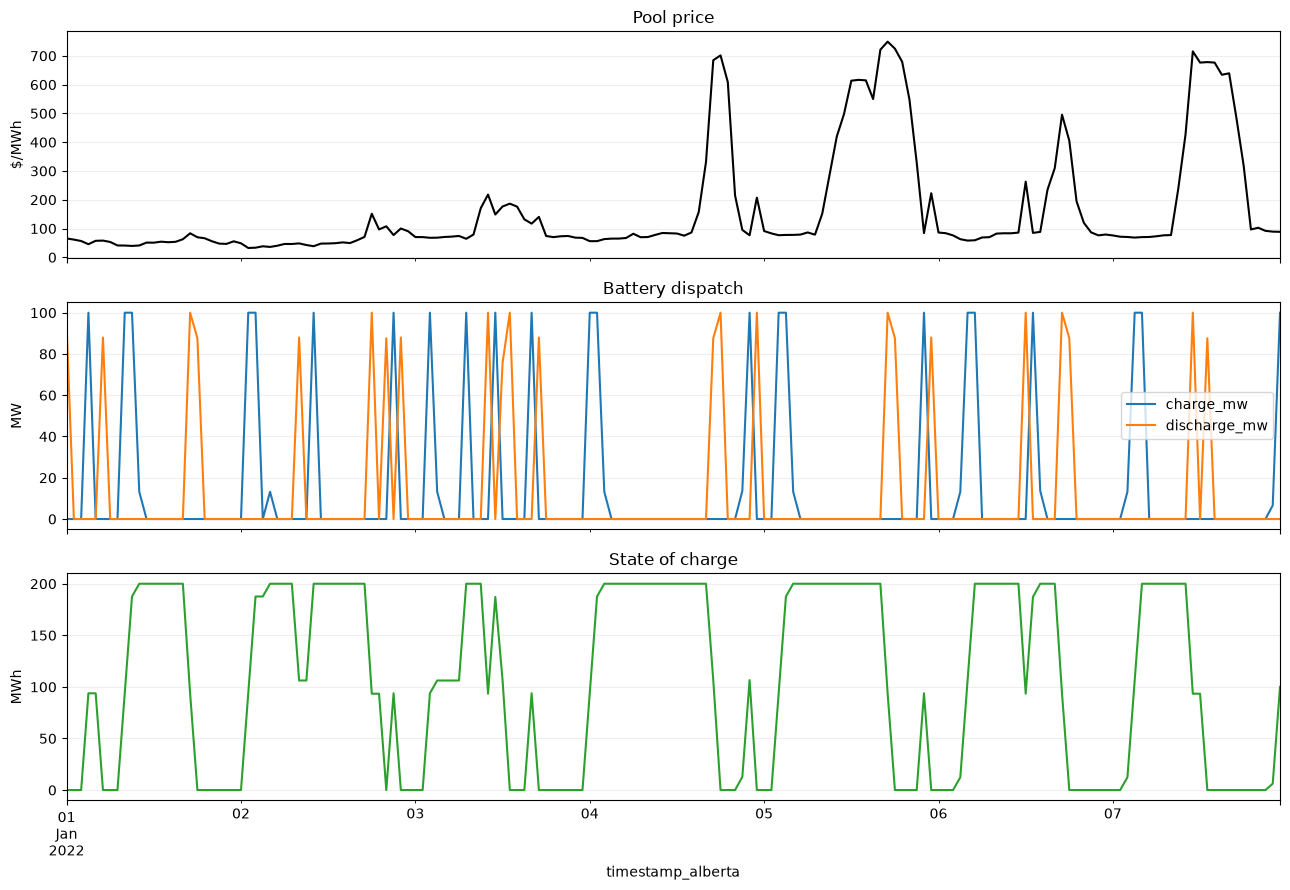

In [36]:
# ---------------------------------------------------------------------
# One-week solver check
# ---------------------------------------------------------------------

smoke_prices = (
    study.loc[
        study["year_alberta"].eq(2022)
    ]
    .set_index("timestamp_alberta")
    ["pool_price"]
    .iloc[:168]
)

smoke_dispatch = optimize_battery_dispatch(
    smoke_prices,
    REFERENCE_BATTERY,
)

smoke_audit = audit_dispatch(
    smoke_dispatch,
    REFERENCE_BATTERY,
)

display(smoke_audit.to_frame("passed"))

if not smoke_audit.all():
    failed_checks = smoke_audit.index[~smoke_audit].tolist()
    raise AssertionError(
        f"Battery dispatch audit failed: {failed_checks}"
    )

display(
    summarize_dispatch(
        smoke_dispatch,
        REFERENCE_BATTERY,
    ).to_frame("value")
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(13, 9),
    sharex=True,
)

smoke_dispatch["price_cad_mwh"].plot(
    ax=axes[0],
    color="black",
    title="Pool price",
)

smoke_dispatch[
    ["charge_mw", "discharge_mw"]
].plot(
    ax=axes[1],
    title="Battery dispatch",
)

smoke_dispatch["soc_end_mwh"].plot(
    ax=axes[2],
    color="tab:green",
    title="State of charge",
)

axes[0].set_ylabel("$/MWh")
axes[1].set_ylabel("MW")
axes[2].set_ylabel("MWh")

for axis in axes:
    axis.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 5. Perfect-foresight upper bound

Optimize each calendar year independently with equal opening and closing SOC. This avoids transferring stored energy between years and produces an annual upper bound thatcan be compared with market regimes. 

Perfect foresight is not an implementable strategy. It is the denomintor against which realistic strategies will be evaluated. 

In [38]:
# ---------------------------------------------------------------------
# Annual perfect-foresight optimization
# ---------------------------------------------------------------------

def optimize_by_year(
    frame, 
    config,
): 
    dispatch_frames = []
    summary_rows = []

    for year, group in frame.groupby("year_alberta", sort = True): 
        prices = group.set_index("timestamp_alberta")["pool_price"]
        dispatch = optimize_battery_dispatch(prices, config)
        audit = audit_dispatch(dispatch, config)

        if not audit.all(): 
            raise RuntimeError(
                f"Dispatch audit failed for {year}:\n"
                f"{audit}"
            )

        dispatch["year_alberta"] = year
        dispatch_frames.append(dispatch)

        summary = summarize_dispatch(dispatch, config)

        summary["year_alberta"] = year
        summary_rows.append(summary)

    annual_dispatch = pd.concat(dispatch_frames)

    annual_summary = (
        pd.DataFrame(summary_rows).set_index("year_alberta")
    )

    return annual_dispatch, annual_summary

if RUN_FULL_STUDY:
    perfect_dispatch, perfect_summary = (
        optimize_by_year(
            study, REFERENCE_BATTERY,
        )
    )

    display(perfect_summary.round(2))
else: 
    print(
        "Set RUN_FULL_STUDY = True "
        "to run the complete annual study"
    )

,gross_revenue_cad,degradation_cost_cad,net_profit_cad,charged_mwh,discharged_mwh,equivalent_full_cycles,profit_per_discharged_mwh
year_alberta,,,,,,,
2015.0,5947610.84,313447.05,5634163.80,83363.58,73359.95,366.80,76.80
2016.0,787802.97,190505.50,597297.47,50666.36,44586.39,222.93,13.40
2017.0,1518708.70,235762.97,1282945.74,62702.92,55178.57,275.89,23.25
2018.0,6475446.55,285369.68,6190076.86,75896.19,66788.65,333.94,92.68
2019.0,8868332.86,361622.09,8506710.77,96176.09,84634.96,423.17,100.51
2020.0,5159190.29,260972.77,4898217.53,69407.65,61078.73,305.39,80.20
2021.0,17846795.52,481689.55,17365105.97,128108.92,112735.85,563.68,154.03
2022.0,28068720.97,594584.65,27474136.32,158134.22,139158.11,695.79,197.43
2023.0,32285893.66,648433.44,31637460.22,172455.70,151761.02,758.81,208.47


## 6. Sources and concentration of value

Decompose profit by:

- year and structural regime;
- month and hour;
- charging and discharging price;
- price band;
- high-price event;
- top 1%, 5%, and 10% of profitable hours.

This determines whether battery value was broadly recurring or depended on a small number of exceptional events.


In [41]:
# ---------------------------------------------------------------------
# Revenue attribution
# ---------------------------------------------------------------------

if RUN_FULL_STUDY:
    attribution = perfect_dispatch.copy()

    attribution["month"] = attribution.index.month
    attribution["hour"] = attribution.index.hour

    attribution["price_band"] = pd.cut(
        attribution["price_cad_mwh"],
        bins=[
            -np.inf,
            50,
            100,
            200,
            500,
            900,
            np.inf,
        ],
        labels=[
            "<50",
            "50–100",
            "100–200",
            "200–500",
            "500–900",
            "900+",
        ],
    )

    profit_by_band = (
        attribution
        .groupby(
            "price_band",
            observed=True,
        )
        ["net_profit_cad"]
        .sum()
    )

    positive_profit = (
        attribution["net_profit_cad"].clip(lower = 0).sort_values(ascending = False)
    )

    concentration = pd.Series({
        "top_1_pct_share": (positive_profit.head(max(1, len(positive_profit) // 100)).sum() / positive_profit.sum()),
        "top_5_pct_share": (positive_profit.head(max(1, len(positive_profit) // 20)).sum() / positive_profit.sum()),
        "top_10_pct_share": (positive_profit.head(max(1, len(positive_profit) // 10)).sum() / positive_profit.sum()),
    })

display(profit_by_band.to_frame("net_profit_cad").round(2))
display(concentration.to_frame("share").round(3))

,net_profit_cad
price_band,
<50,-11092716.01
50–100,912083.44
100–200,14460695.36
200–500,42267962.89
500–900,60962560.40
900+,21770825.02


,share
top_1_pct_share,0.387
top_5_pct_share,0.857
top_10_pct_share,0.984


## 7. Causal rule-based benchmarks

Implementable strategies must use only information available before dispatch.

Begin with three deliberately simple benchmarks:

1. prior-day hourly prices;
2. trailing 30-day price quantiles;
3. trailing hour-of-day price expectations.

All strategies must use the same battery assumptions and terminal-value convention as the perfect-foresight model.

In [42]:
# ---------------------------------------------------------------------
# Construct causal rule inputs
# ---------------------------------------------------------------------

rule_frame = study[
    [
        "timestamp_utc",
        "timestamp_alberta",
        "year_alberta",
        "hour_alberta",
        "pool_price",
    ]
].copy()

rule_frame["price_lag_24h"] = (rule_frame["pool_price"].shift(24))
rule_frame["trailing_low"] = (rule_frame["pool_price"].shift(1).rolling(24 * 30, min_periods=24 * 7).quantile(0.25))
rule_frame["trailing_high"] = (rule_frame["pool_price"].shift(1).rolling(24 * 30, min_periods=24 * 7).quantile(0.75))

# TODO:
# Build a sequential policy simulator that:
# 1. updates SOC after every decision;
# 2. respects efficiency and power constraints;
# 3. prevents simultaneous charging/discharging;
# 4. applies a consistent terminal-SOC or salvage-value rule;
# 5. returns the same economic columns as the optimizer.

## 8. Battery-design sensitivity

Use a compact prespecified grid rather than searching arbitrary configurations.

Test:

- 50 MW and 100 MW power ratings;
- 1-, 2-, and 4-hour durations;
- 80%, 88%, and 92% round-trip efficiency;
- degradation costs of \$0, \$2, and \$5/MWh of throughput.

Report total profit, profit per MW, profit per MWh of capacity, equivalent cycles, and revenue concentration.

In [ ]:
# ---------------------------------------------------------------------
# Prespecified sensitivity grid
# ---------------------------------------------------------------------

sensitivity_grid = pd.DataFrame(
    product(
        [50.0, 100.0],
        [1.0, 2.0, 4.0],
        [0.80, 0.88, 0.92],
        [0.0, 2.0, 5.0],
    ),
    columns=[
        "power_mw",
        "duration_hours",
        "round_trip_efficiency",
        "degradation_cost_per_mwh",
    ],
)

sensitivity_grid["energy_mwh"] = (sensitivity_grid["power_mw"] * sensitivity_grid["duration_hours"])

display(sensitivity_grid.head())

# TODO:
# Run each configuration by year.
# Preserve dispatch audits for every run.
# Present duration × efficiency heatmaps by market regime.

,power_mw,duration_hours,round_trip_efficiency,degradation_cost_per_mwh,energy_mwh
0,50.0,1.0,0.80,0.0,50.0
1,50.0,1.0,0.80,2.0,50.0
2,50.0,1.0,0.80,5.0,50.0
3,50.0,1.0,0.88,0.0,50.0
4,50.0,1.0,0.88,2.0,50.0


## 9. Final synthesis

The reference 100 MW / 200 MWh battery produced an estimated $129.3 million in perfect-foresight net energy-arbitrage margin from 2015 through 2025, after applying the assumed $2/MWh throughput degradation charge. Annual value varied substantially across market regimes: it fell to approximately $0.6 million in 2016, increased to $17.4 million in 2021, and peaked at $31.6 million in 2023**. The 2021–2023 period alone contributed 59.2% of the eleven-year total. Margins declined to $13.8 million in 2024 and $11.9 million in 2025 but remained above most pre-2021 results.

Value was highly concentrated in expensive hours. Hours priced above $500/MWh contributed approximately $82.7 million, equivalent to about 64% of the final net margin. The top 1% of all study hours generated 38.7% of positive hourly profit, while the top 5% generated 85.7%. Conversely, hours below $50/MWh produced a net contribution of −$11.1 million because they were primarily used to purchase charging energy. The battery’s historical value therefore depended on combining relatively inexpensive charging opportunities with a limited number of extreme-price events.

Battery utilization also changed with market conditions. Annual equivalent full cycles ranged from 223 in 2016 to 759 in 2023. Cycling remained high in 2024 and 2025, but profit per discharged MWh fell from $208 in 2023 to $103 and $95, respectively. This indicates that additional cycling does not necessarily create comparable value when price spreads narrow. The 2023 result—approximately 2.1 equivalent cycles per day—also suggests that realistic cycle-life and degradation constraints could materially reduce the perfect-foresight result.

The battery-duration, efficiency, and degradation sensitivities have not yet been executed. The notebook has defined a prespecified grid covering 1-, 2-, and 4-hour batteries, round-trip efficiencies from 80% to 92%, and degradation charges from $0 to $5/MWh, but no comparative results should be reported until those simulations are complete.

Likewise, the causal strategy evaluation remains unfinished. Forecast-safe inputs based on prior-day prices and trailing price distributions have been constructed, but the sequential dispatch policies have not yet been simulated. The current results therefore establish a theoretical upper bound rather than the proportion of value that could have been captured using information available at the time of dispatch.

The most stable finding is that Alberta battery-arbitrage value is strongly regime-dependent and concentrated in extreme-price intervals. High cycling alone is insufficient: profitability depends on the magnitude and timing of the available price spreads. Completing the causal benchmarks and battery-design sensitivities will determine how much of this historical opportunity survives under more realistic information and operating constraints.

These results describe historical energy-arbitrage potential under perfect foresight. The reported net margin deducts only the simplified throughput degradation charge and excludes capital cost, fixed operating cost, market fees, price impact, forced outages, calendar degradation, ancillary-service revenue, and financing. It should not be interpreted as live trading performance, an operational dispatch recommendation, or an investment-grade valuation.